# LLaMA

## LLaMA fine-tuning on SEND transcripts to predict affective valence

In [1]:
import os
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
from model_send_text import preprocess_text_data, load_text_inputs, run_llama

In [2]:
with open("../private/llama.txt", "r") as file:
    access_token = file.read()

### 1. Preprocess text inputs

#### Supplementary Table 8

Preprocess data from the Stanford Emotional Narratives Dataset (SEND). Data (not included in this repo) were collected and annotated as described in Ong et al. (2021), and were provided by Dr. Ong to be used in accordance with the end-user license agreement. The subset of the data with available video clips are preprocessed into transcript inputs that can be used to fine-tune a text-based model. Models are fine-tuned to predict the labels for affective valence in the SEND dataset averaged within 10-, 20-, and 30-second windows. The original splits for train, validation, and test sets in the Ong et al. paper are preserved here.

In [3]:
segment_duration_levels = [30, 20, 10]

In [4]:
for segment_duration in segment_duration_levels:
    preprocess_text_data("data/raw/with-video/text", "data/raw/ratings", segment_duration, 
                         splits=["train", "valid", "test"])

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of texts:     263
Max words/text:      136
Median words/text:   77
Mean words/text:     76.93
Std dev words/text:  23.37

VALID SPLIT
Number of texts:     133
Max words/text:      112
Median words/text:   74
Mean words/text:     71.49
Std dev words/text:  24.13

TEST SPLIT
Number of texts:     152
Max words/text:      131
Median words/text:   87
Mean words/text:     84.25
Std dev words/text:  21.76

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of texts:     387
Max words/text:      94
Median words/text:   53
Mean words/text:     52.28
Std dev words/text:  15.96

VA

### 2. Specify training parameters

Input data are segmented over different clip segment durations. Hyperparameters tuned here are dropout levels.

In [5]:
model_name = "Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(f"meta-llama/{model_name}", token=access_token)
tokenizer.pad_token = tokenizer.eos_token

max_length = 100
n_epochs_levels = [50]
attn_dropout_levels = [0, 0.1, 0.4]
constant_params = {"lr": 0.00005, 
                   "tune_layer": 15, 
                   "batch_size": 1, 
                   "warmup_steps": 500,
                   "device": "mps:0",
                   "access_token": access_token}

### 3. Train models over a range of hyperparameters

In [6]:
validation = []
for segment_duration in segment_duration_levels:
    
    data = load_text_inputs("data/texts", segment_duration, tokenizer,
                            max_length=max_length, splits=["train", "valid"])

    for n_epochs in n_epochs_levels:
        for attn_dropout in attn_dropout_levels:
            model_path, model_eval = run_llama(model_name, tokenizer, data,
                                               segment_duration=segment_duration,
                                               n_epochs=n_epochs,
                                               attn_dropout=attn_dropout,
                                               **constant_params,
                                               splits=["train", "valid"],
                                               plot=False)
    
            validation += model_eval  
            df = pd.DataFrame(validation)
            df.to_csv(f"tables/{model_name}_validation.csv", index=False)

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/263 [00:00<?, ? examples/s]

Map:   0%|          | 0/132 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-1B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...


TRAINING MODEL
Path: models/10s/Llama-3.2-1B/Llama-3.2-1B_10s_epochs50_lr5e-05_drop-attn0.4_tune15



Epoch,Training Loss,Validation Loss,Rmse
1,0.899600,0.458008,0.507866
2,0.337200,0.233634,0.282866
3,0.300400,0.201537,0.241593
4,0.276000,0.231701,0.281887
5,0.242600,0.165267,0.223665
6,0.236400,0.228813,0.290124
7,0.222500,0.374039,0.434057
8,0.225100,0.192762,0.254052
9,0.212900,0.171684,0.244696
10,0.211400,0.188636,0.263900


EVALUATING MODEL


TRAIN   Mean: 0.53390   SD: 0.23140   RMSE: 0.08470   R: 0.93318 (p=0.00000)   CCC: 0.93232 (p=0.00000)


VALID   Mean: 0.54944   SD: 0.17532   RMSE: 0.20699   R: 0.47200 (p=0.00000)   CCC: 0.45391 (p=0.00000)

----------------------------------------------------------------------------------------------------



### 4. Select model by validation set performance

In [7]:
df = pd.read_csv(f"results/{model_name}_validation.csv")
valid_params = {}
for segment_duration in segment_duration_levels:
    
    segment_df = df[df["segment_duration"] == segment_duration]
    top_df = segment_df[segment_df["split"] == "valid"].sort_values("ccc", ascending=False)
    top_dict = top_df.to_dict(orient="records")[0]
    
    valid_params[segment_duration] = {"n_epochs": top_dict["n_epochs"],
                                      "attn_dropout": top_dict["attn_dropout"]}
    
    print("-"*100 + f"\nTOP MODELS FOR {segment_duration}-SECOND SEGMENTS")
    print(top_df[["n_epochs", "attn_dropout", "ccc", "ccc_p"]])
    print()

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 30-SECOND SEGMENTS
   n_epochs  attn_dropout       ccc  ccc_p
5        50           0.4  0.533650    0.0
3        50           0.1  0.468785    0.0
1        50           0.0  0.457277    0.0

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 20-SECOND SEGMENTS
    n_epochs  attn_dropout       ccc  ccc_p
11        50           0.4  0.521047    0.0
9         50           0.1  0.468739    0.0
7         50           0.0  0.408673    0.0

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 10-SECOND SEGMENTS
    n_epochs  attn_dropout       ccc  ccc_p
17        50           0.4  0.453911    0.0
15        50           0.1  0.419037    0.0
13        50           0.0  0.417453    0.0



### 5. Evaluate model on the test set

#### Supplementary Tables 9-10

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/263 [00:00<?, ? examples/s]

Map:   0%|          | 0/132 [00:00<?, ? examples/s]

Map:   0%|          | 0/152 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-1B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/30s/Llama-3.2-1B/Llama-3.2-1B_30s_epochs50_lr5e-05_drop-attn0.4_tune15

EVALUATING MODEL


TRAIN   Mean: 0.48707   SD: 0.29340   RMSE: 0.11778   R: 0.95997 (p=0.00000)   CCC: 0.90166 (p=0.00000)


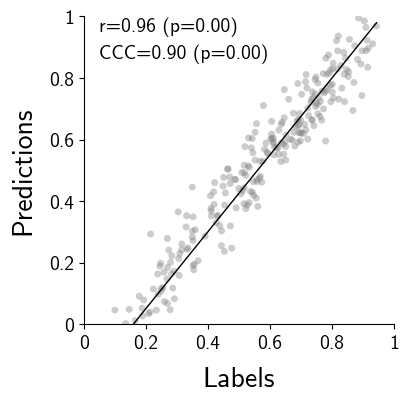

VALID   Mean: 0.50564   SD: 0.16659   RMSE: 0.18914   R: 0.55678 (p=0.00000)   CCC: 0.53365 (p=0.00000)


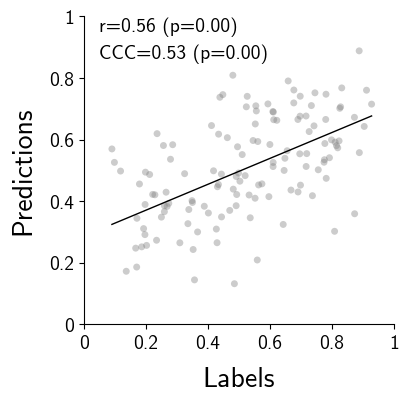

TEST    Mean: 0.48405   SD: 0.18528   RMSE: 0.17460   R: 0.64720 (p=0.00000)   CCC: 0.62453 (p=0.00000)


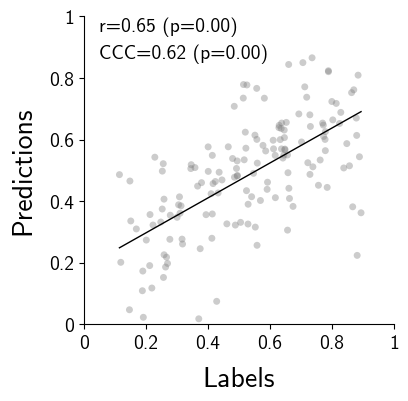


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/387 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/221 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-1B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/20s/Llama-3.2-1B/Llama-3.2-1B_20s_epochs50_lr5e-05_drop-attn0.4_tune15

EVALUATING MODEL


TRAIN   Mean: 0.55146   SD: 0.28239   RMSE: 0.09902   R: 0.94652 (p=0.00000)   CCC: 0.92570 (p=0.00000)


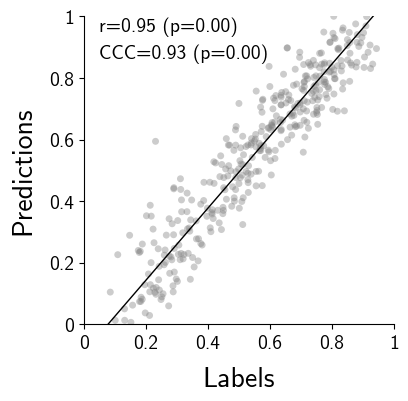

VALID   Mean: 0.56698   SD: 0.18164   RMSE: 0.19897   R: 0.54822 (p=0.00000)   CCC: 0.52105 (p=0.00000)


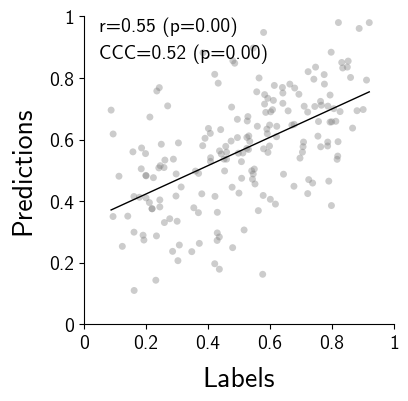

TEST    Mean: 0.56001   SD: 0.19919   RMSE: 0.16629   R: 0.68503 (p=0.00000)   CCC: 0.67745 (p=0.00000)


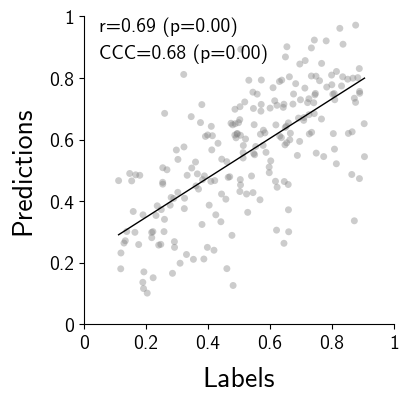


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
10-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/741 [00:00<?, ? examples/s]

Map:   0%|          | 0/362 [00:00<?, ? examples/s]

Map:   0%|          | 0/431 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-1B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/Llama-3.2-1B/Llama-3.2-1B_10s_epochs50_lr5e-05_drop-attn0.4_tune15

EVALUATING MODEL


TRAIN   Mean: 0.53390   SD: 0.23140   RMSE: 0.08470   R: 0.93318 (p=0.00000)   CCC: 0.93232 (p=0.00000)


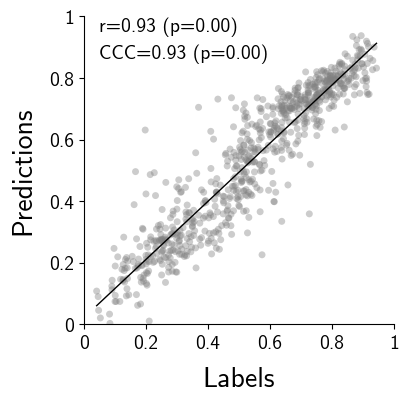

VALID   Mean: 0.54944   SD: 0.17532   RMSE: 0.20699   R: 0.47200 (p=0.00000)   CCC: 0.45391 (p=0.00000)


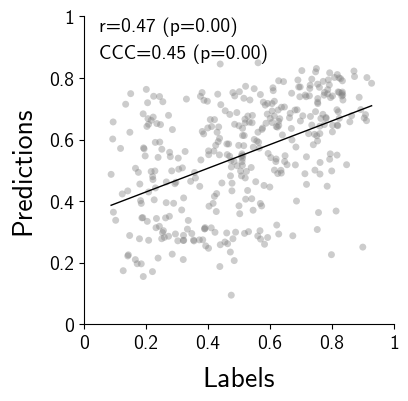

TEST    Mean: 0.53911   SD: 0.18380   RMSE: 0.19326   R: 0.53124 (p=0.00000)   CCC: 0.52572 (p=0.00000)


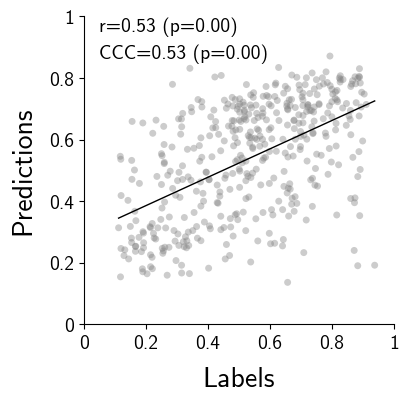


----------------------------------------------------------------------------------------------------



In [8]:
evaluation_splits = ["train", "valid", "test"]
evaluation = []
for segment_duration in segment_duration_levels:
    
    data = load_text_inputs("data/texts", segment_duration, tokenizer,
                            max_length=max_length, splits=evaluation_splits)
    
    model_path, model_eval = run_llama(model_name, tokenizer, data,
                                       segment_duration=segment_duration,
                                       n_epochs=valid_params[segment_duration]["n_epochs"],
                                       attn_dropout=valid_params[segment_duration]["attn_dropout"],
                                       **constant_params,
                                       splits=evaluation_splits,
                                       plot=True)

    evaluation += model_eval

evaluation_df = pd.DataFrame(evaluation)
evaluation_df.to_csv(f"tables/{model_name}_evaluation.csv", index=False)